# Make a 2D/3D box around Kirishima, add Cerjean boundaries, propagate elastic and acoustic waves and thermal diffusion

In [1]:
# Locate flexOPT securely without relying on @__DIR__ (unreliable in IJulia).
# If this notebook is outside the repository, set ENV["FLEXOPT_ROOT"] first.
import Pkg

function find_flexopt_root(start_dir=pwd())
    candidates = String[]
    if haskey(ENV, "FLEXOPT_ROOT")
        push!(candidates, abspath(expanduser(ENV["FLEXOPT_ROOT"])))
    end
    directory = abspath(start_dir)
    while true
        push!(candidates, directory)
        parent = dirname(directory)
        parent == directory && break
        directory = parent
    end
    for candidate in unique(candidates)
        project_file = joinpath(candidate, "Project.toml")
        source_dir = joinpath(candidate, "src")
        if isfile(project_file) && isfile(joinpath(source_dir, "commonBatchs.jl"))
            return candidate
        end
    end
    error("Cannot locate flexOPT. Start Jupyter inside the repository or set ENV[\"FLEXOPT_ROOT\"] to its absolute path.")
end

flexopt_root = find_flexopt_root()
Pkg.activate(flexopt_root)
@show VERSION Threads.nthreads() Base.active_project()

include(joinpath(flexopt_root, "src", "commonBatchs.jl"))
include(joinpath(flexopt_root, "src", "planet1D.jl"))
planet1D.configure_input!()
include(joinpath(flexopt_root, "src", "GeoPoints.jl"))
using .commonBatchs, .planet1D, .GeoPoints


  Activating 

VERSION = v"1.12.6"
Threads.nthreads() = 8
Base.active_project() = "/Users/nobuaki/Documents/Github/flexOPT/Project.toml"


project at `~/Documents/Github/flexOPT`


In [5]:
using Makie

In [3]:
p0=GeoPoint(dmsToDecimal(31,56,03),dmsToDecimal(130,51,42)) # Kirishima

Δx = 100.0 # in metre
Δy = 100.0
Δz = 100.0
altMax = 2.e3 # in metre
altMin = -5.e3 # in metre
horizontalDepth=5.e3
boxGrids3D=constructLocalBox(p0,Δx,Δy,Δz,-horizontalDepth,horizontalDepth,-horizontalDepth,horizontalDepth,altMin,altMax)
seismicModel3D=lazyProduceOrLoad("seismicModel3D_Kirishima",getParamsAndTopo,boxGrids3D.allGridsInGeoPoints,boxGrids3D.effectiveRadii,0.1)

centreOption = "p0"
Computing seismicModel3D_Kirishima


[ Info: File /Users/nobuaki/Documents/Github/flexOPT/data/topoViaGMT/topoViaGMT_8f12ecd7.jld2 does not exist. Producing it now...
grdblend [NOTICE]: Remote data courtesy of GMT data server oceania [http://oceania.generic-mapping-tools.org]

grdblend [NOTICE]: Earth Relief at 3x3 arc seconds tiles provided by SRTMGL3 (land only) [NASA/USGS].
grdblend [NOTICE]:   -> Download 1x1 degree grid tile (earth_relief_03s_g): N31E130
┌ Warning: The Git repository ('/Users/nobuaki/Documents/Github/flexOPT') is dirty! Appending -dirty to the commit ID.
└ @ DrWatson ~/.julia/packages/DrWatson/2QF5p/src/saving_tools.jl:71
[ Info: File /Users/nobuaki/Documents/Github/flexOPT/data/topoViaGMT/topoViaGMT_8f12ecd7.jld2 saved.


(ρ = [2.6 2.6 … 2.6 2.6; 2.6 2.5999999999999996 … 2.5999999999999996 2.6000000000000005; … ; 2.6 2.6 … 2.6 2.6; 2.5999999999999996 2.6000000000000005 … 2.6 2.6000000000000005;;; 2.6 2.6 … 2.6 2.6000000000000005; 2.6 2.6 … 2.6000000000000005 2.6; … ; 2.6 2.6 … 2.5999999999999996 2.6; 2.6 2.6 … 2.6 2.6;;; 2.6 2.6 … 2.5999999999999996 2.6; 2.6 2.6000000000000005 … 2.6000000000000005 2.6; … ; 2.6 2.6 … 2.6 2.6; 2.5999999999999996 2.6 … 2.6000000000000005 2.6;;; … ;;; 0.001 0.001 … 0.001 0.001; 0.001 0.001 … 0.001 0.001; … ; 0.001 0.001 … 0.001 0.001; 0.001 0.001 … 0.001 0.001;;; 0.001 0.001 … 0.001 0.001; 0.001 0.001 … 0.001 0.001; … ; 0.001 0.001 … 0.001 0.001; 0.001 0.001 … 0.001 0.001;;; 0.001 0.001 … 0.001 0.001; 0.001 0.001 … 0.001 0.001; … ; 0.001 0.001 … 0.001 0.001; 0.001 0.001 … 0.001 0.001], Vpv = [5.8 5.8 … 5.799999999999999 5.799999999999999; 5.8 5.799999999999999 … 5.799999999999999 5.8; … ; 5.799999999999999 5.799999999999999 … 5.800000000000001 5.800000000000001; 5.8 5.8 … 5

original size = (101, 101, 71)
plot size = (101, 101, 71)
strides = (1, 1, 1)


┌ Warning: Volume{Tuple{MakieCore.EndPoints{Float64}, MakieCore.EndPoints{Float64}, MakieCore.EndPoints{Float64}, Array{Float32, 3}}} is not supported by cairo right now
└ @ CairoMakie ~/.julia/packages/CairoMakie/Yu6dt/src/infrastructure.jl:186
┌ Warning: Volume{Tuple{MakieCore.EndPoints{Float64}, MakieCore.EndPoints{Float64}, MakieCore.EndPoints{Float64}, Array{Float32, 3}}} is not supported by cairo right now
└ @ CairoMakie ~/.julia/packages/CairoMakie/Yu6dt/src/infrastructure.jl:186


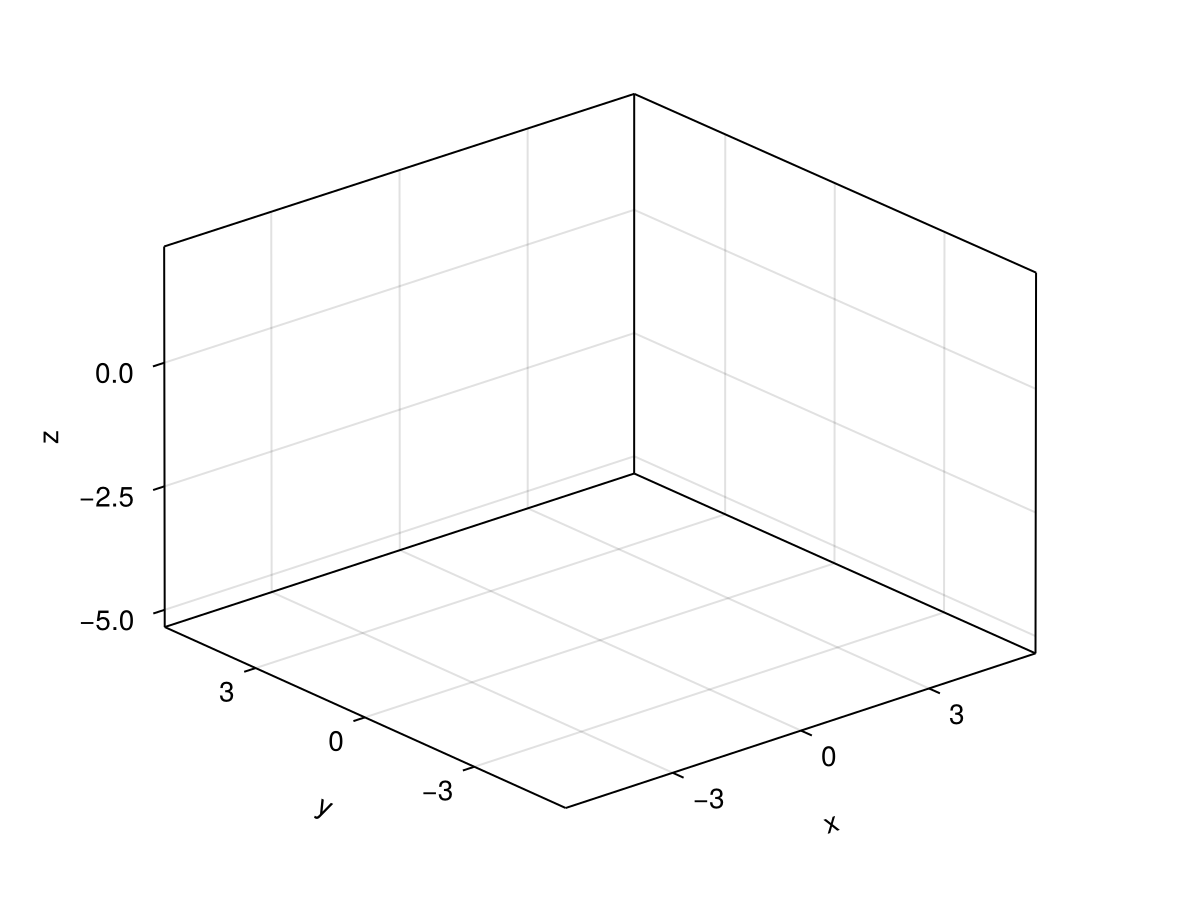

In [6]:

x = [p.xyz[1] for p in boxGrids3D.allGridsInCartesian[:,1,1]]*1.e-3
y = [p.xyz[2] for p in boxGrids3D.allGridsInCartesian[1,:,1]]*1.e-3
z = [p.xyz[3] for p in boxGrids3D.allGridsInCartesian[1,1,:]]*1.e-3

ρ = seismicModel3D.ρ

sx = max(1, ceil(Int, size(ρ, 1) / 512))
sy = max(1, ceil(Int, size(ρ, 2) / 512))
sz = max(1, ceil(Int, size(ρ, 3) / 256))

ρ_plot = ρ[1:sx:end, 1:sy:end, 1:sz:end]
xg = x[1:sx:end]
yg = y[1:sy:end]
zg = z[1:sz:end]

println("original size = ", size(ρ))
println("plot size = ", size(ρ_plot))
println("strides = ", (sx, sy, sz))




f = Figure()
ax = Axis3(f[1, 1])

volume!(
    ax,
    xg[1] .. xg[end],
    yg[1] .. yg[end],
    zg[1] .. zg[end],
    ρ_plot;
    algorithm = :absorption,
    colormap = :viridis,
)
f